In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os

sns.set_theme(style="ticks")
sns.set_context("poster", font_scale=2)
sns.set_palette("Set1", 10)
sns.set_style({"font.family": "serif", "font.serif": "Times New Roman"})

if Path.cwd().name != 'workdir':
    os.chdir('../../workdir')

print(Path.cwd())
figure_dir_path = Path(r"C:\Users\htsai\src\2024-Defend-Transferable-Jailbreak-with-Speculative-Inference\figures")
dataset_name = "RPAB"

c:\Users\htsai\src\proj-jailbreak-sandbox\workdir


In [14]:
target_model_map = {
    "Meta-Llama-3-70B-Instruct-AWQ": "Llama-3",
    "Qwen1.5-72B-Chat-AWQ": "Qwen-1.5",
    "Phi-3-medium-128k-instruct": "Phi-3",
}

def construct_dataframe(dataset_name, draft_model_name, ground_truth_guard_name):
    result = []
    for target_model_name in [
        "Meta-Llama-3-70B-Instruct-AWQ",
        "Qwen1.5-72B-Chat-AWQ",
        "Phi-3-medium-128k-instruct",
    ]:
        for generation_name in ["GCG", "AutoDAN"]:
            for draft_number in range(5, 35 + 1, 5):
                for ratio in range(0, 100, 10):
                    ratio_percentage = ratio / 100
                    path = (
                        Path.cwd()
                        / "step_7_result"
                        / dataset_name
                        / target_model_name
                        / generation_name
                        / draft_model_name
                        / f"{ground_truth_guard_name}_{ratio_percentage}.pkl"
                    )
                    df = pd.read_pickle(path)
                    ASR = df.loc[f"sandbox_{draft_number}"]["ASR"]
                    result.append(
                        {
                            "Draft Number": draft_number,
                            "Ratio": ratio,
                            "ASR": ASR,
                            "Target Model": target_model_map[target_model_name],
                            "Draft Model": draft_model_name,
                            "Generation": generation_name,
                        }
                    )
    df = pd.DataFrame(result)
    return df

c:\Users\htsai\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\htsai\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\htsai\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\htsai\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to acc

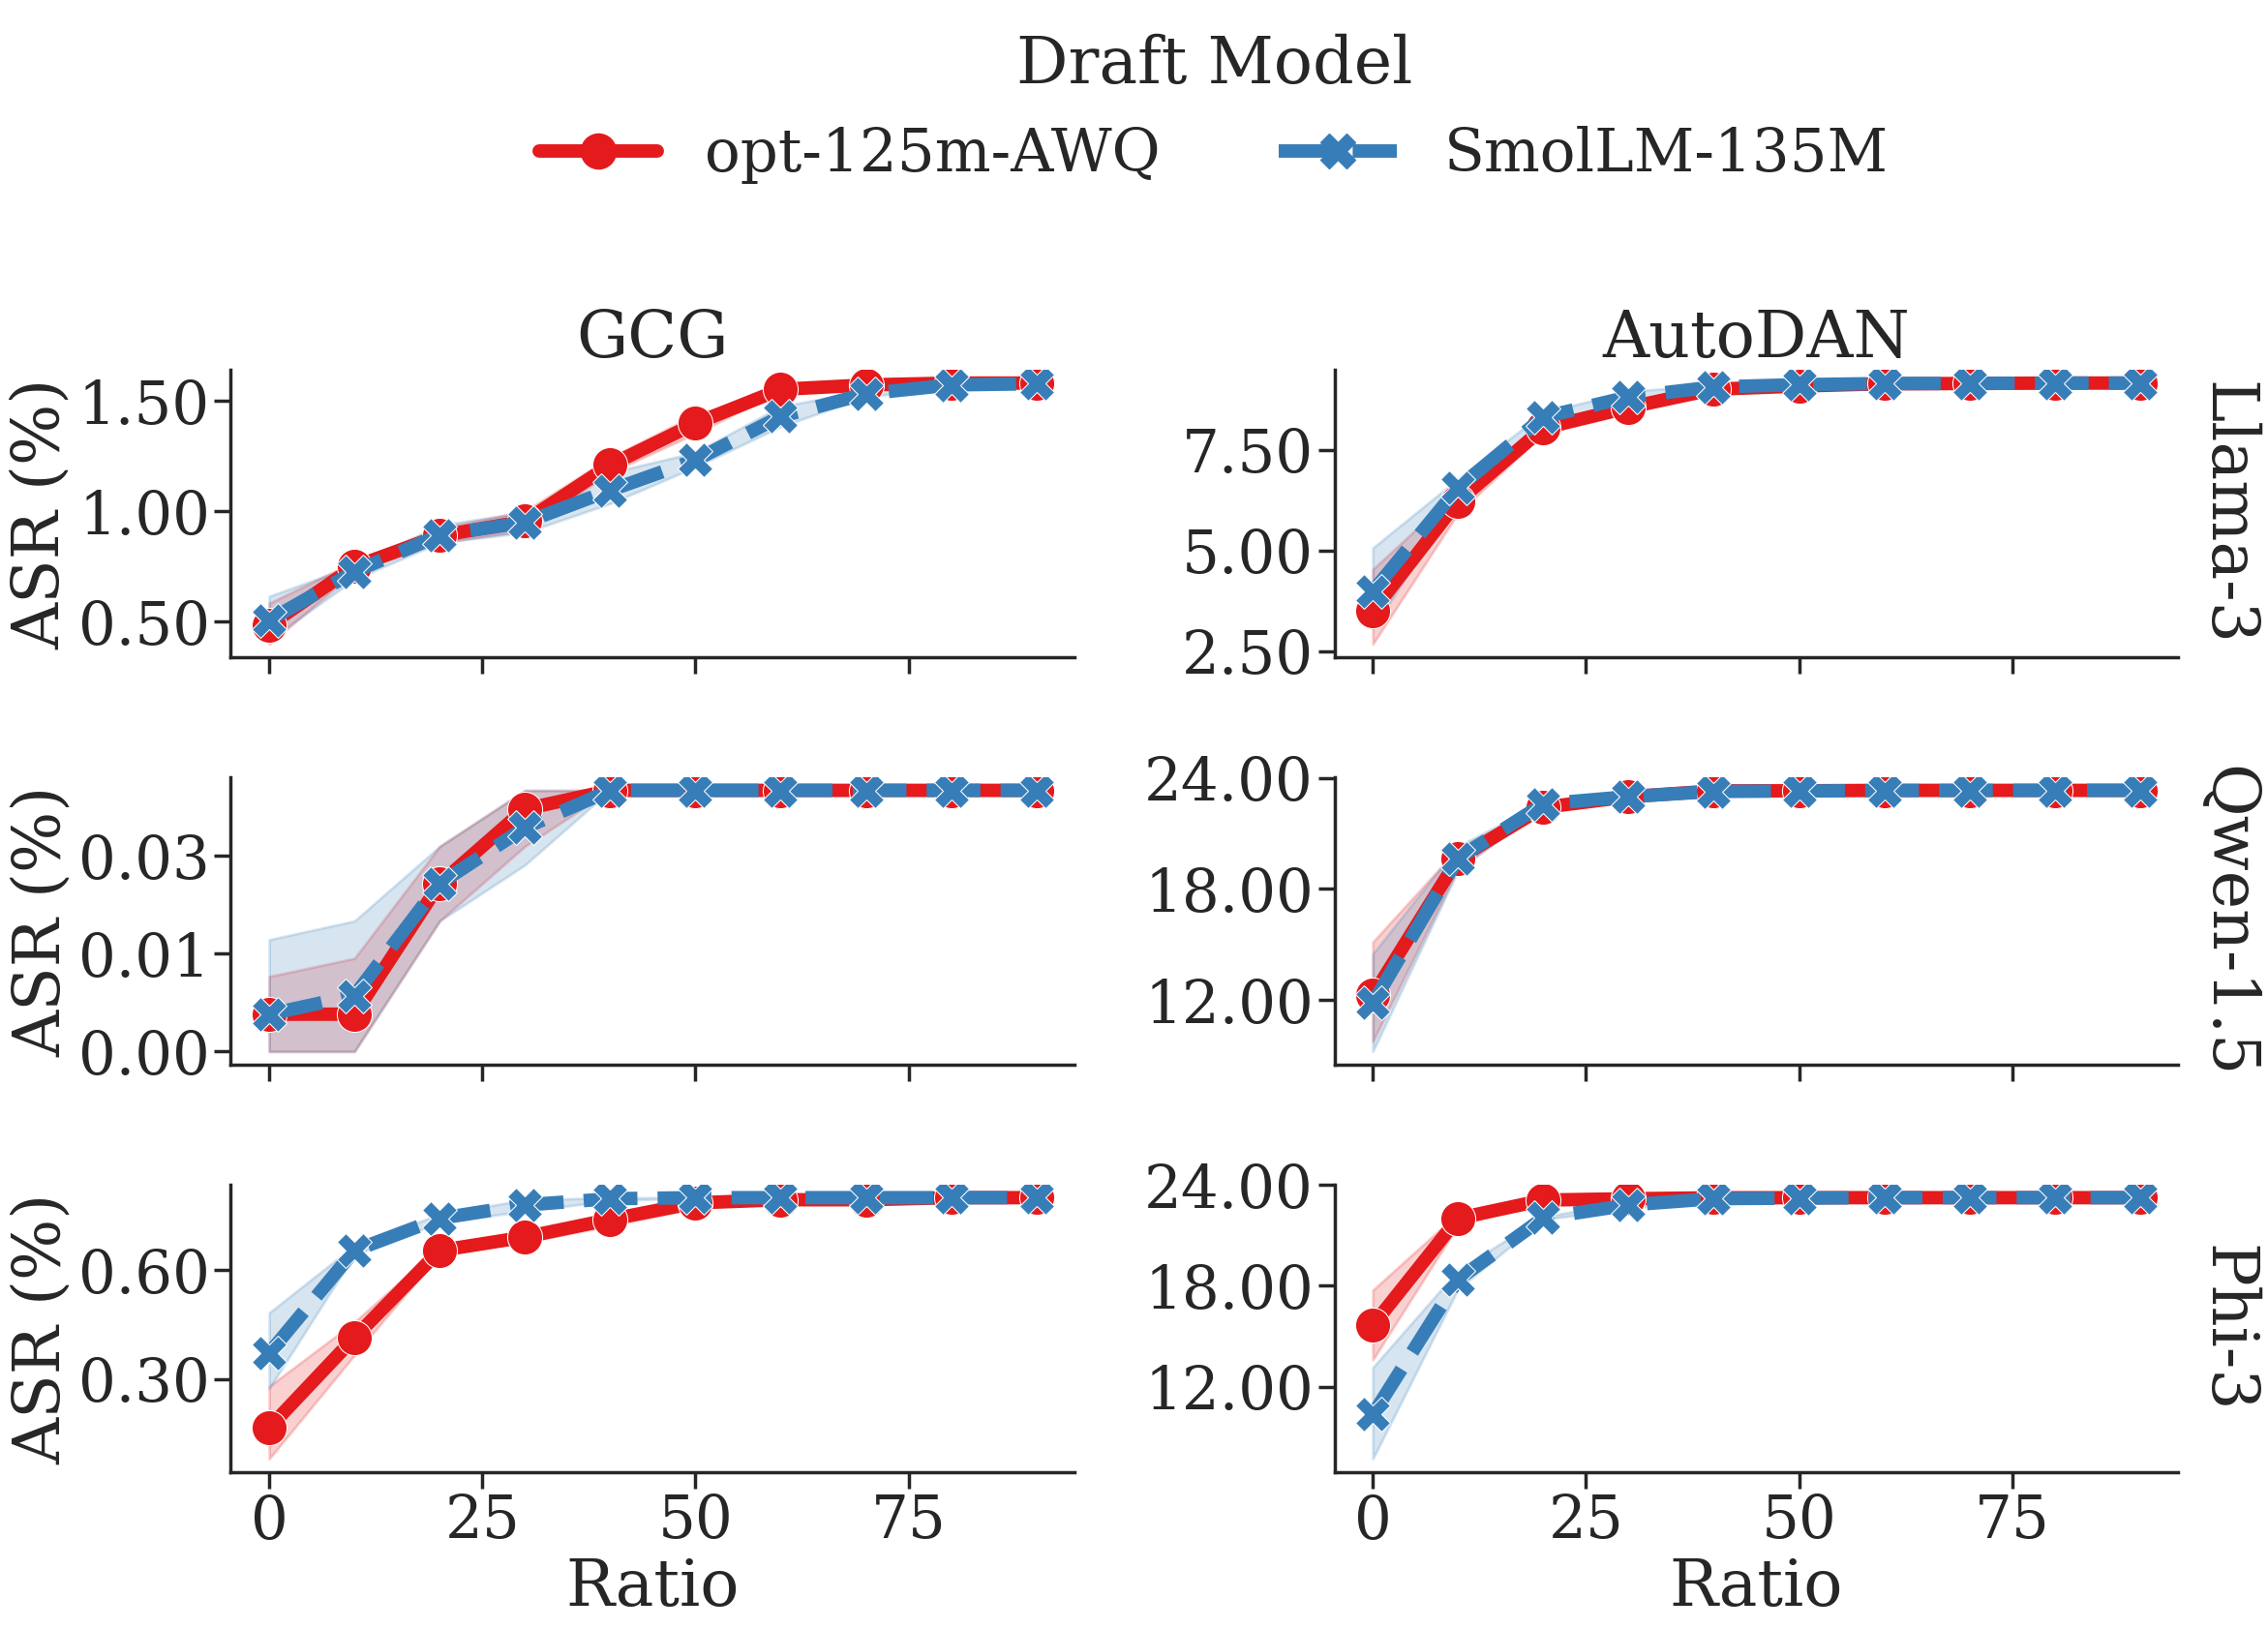

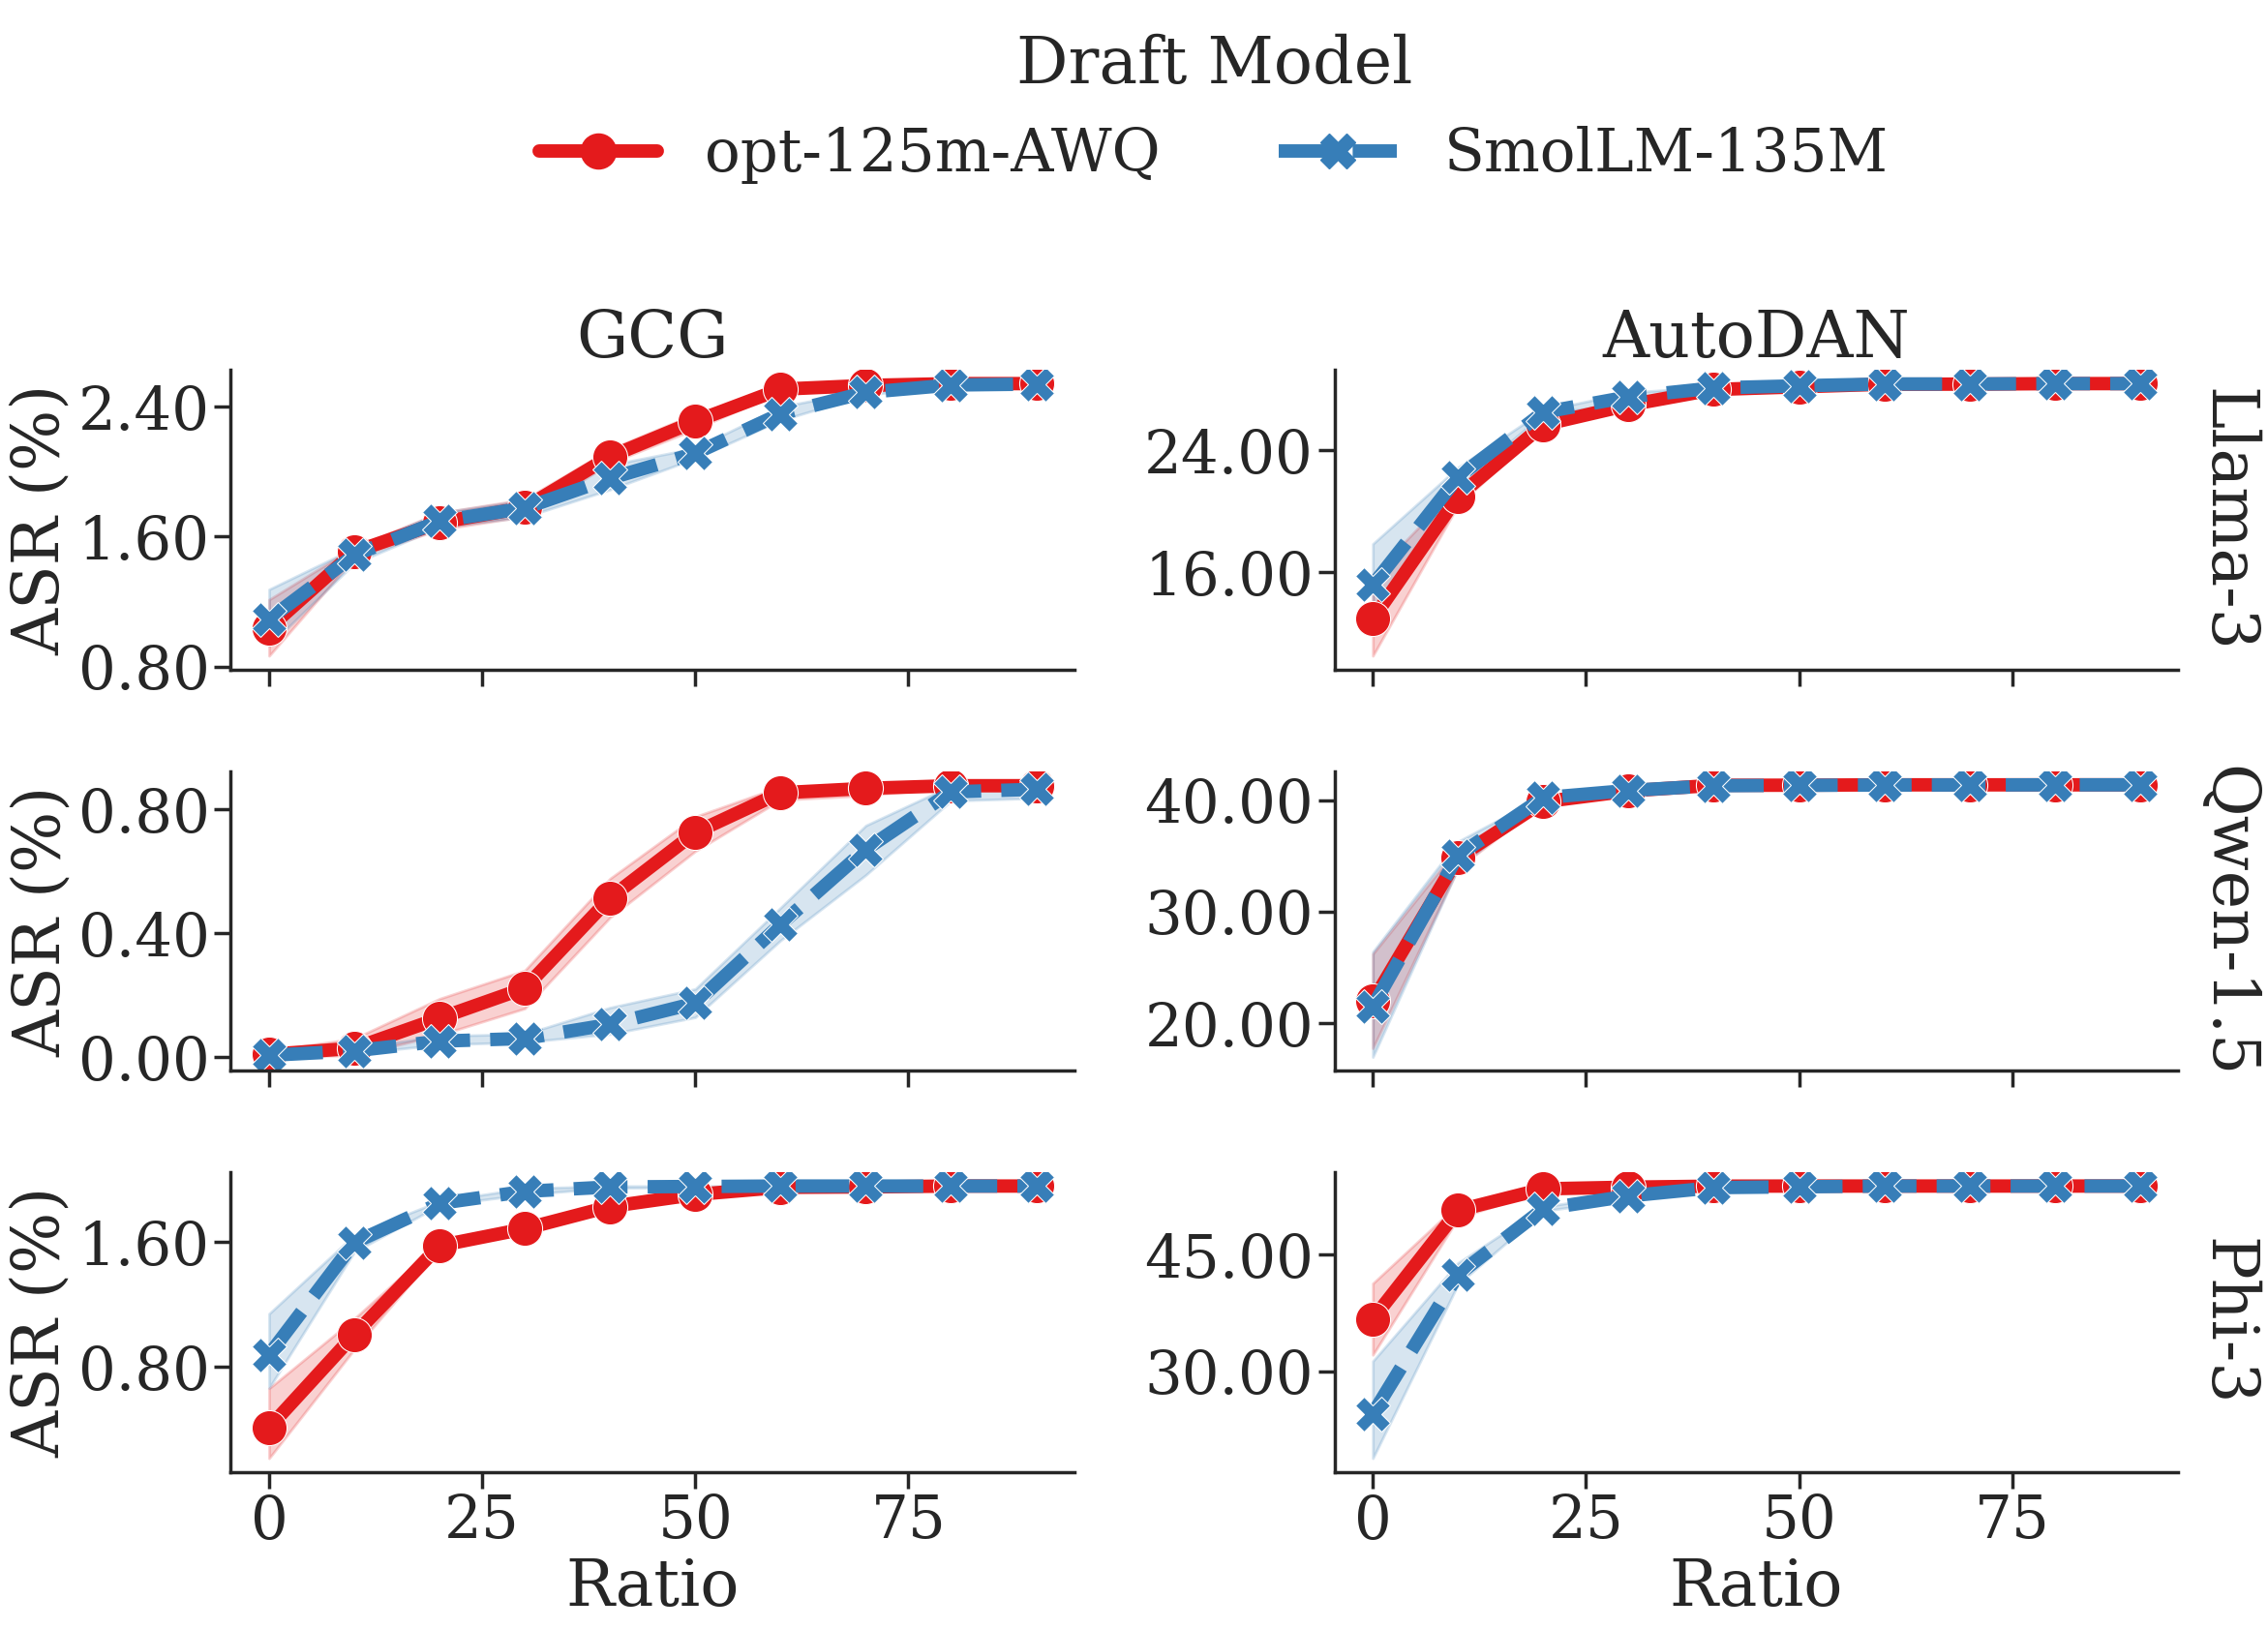

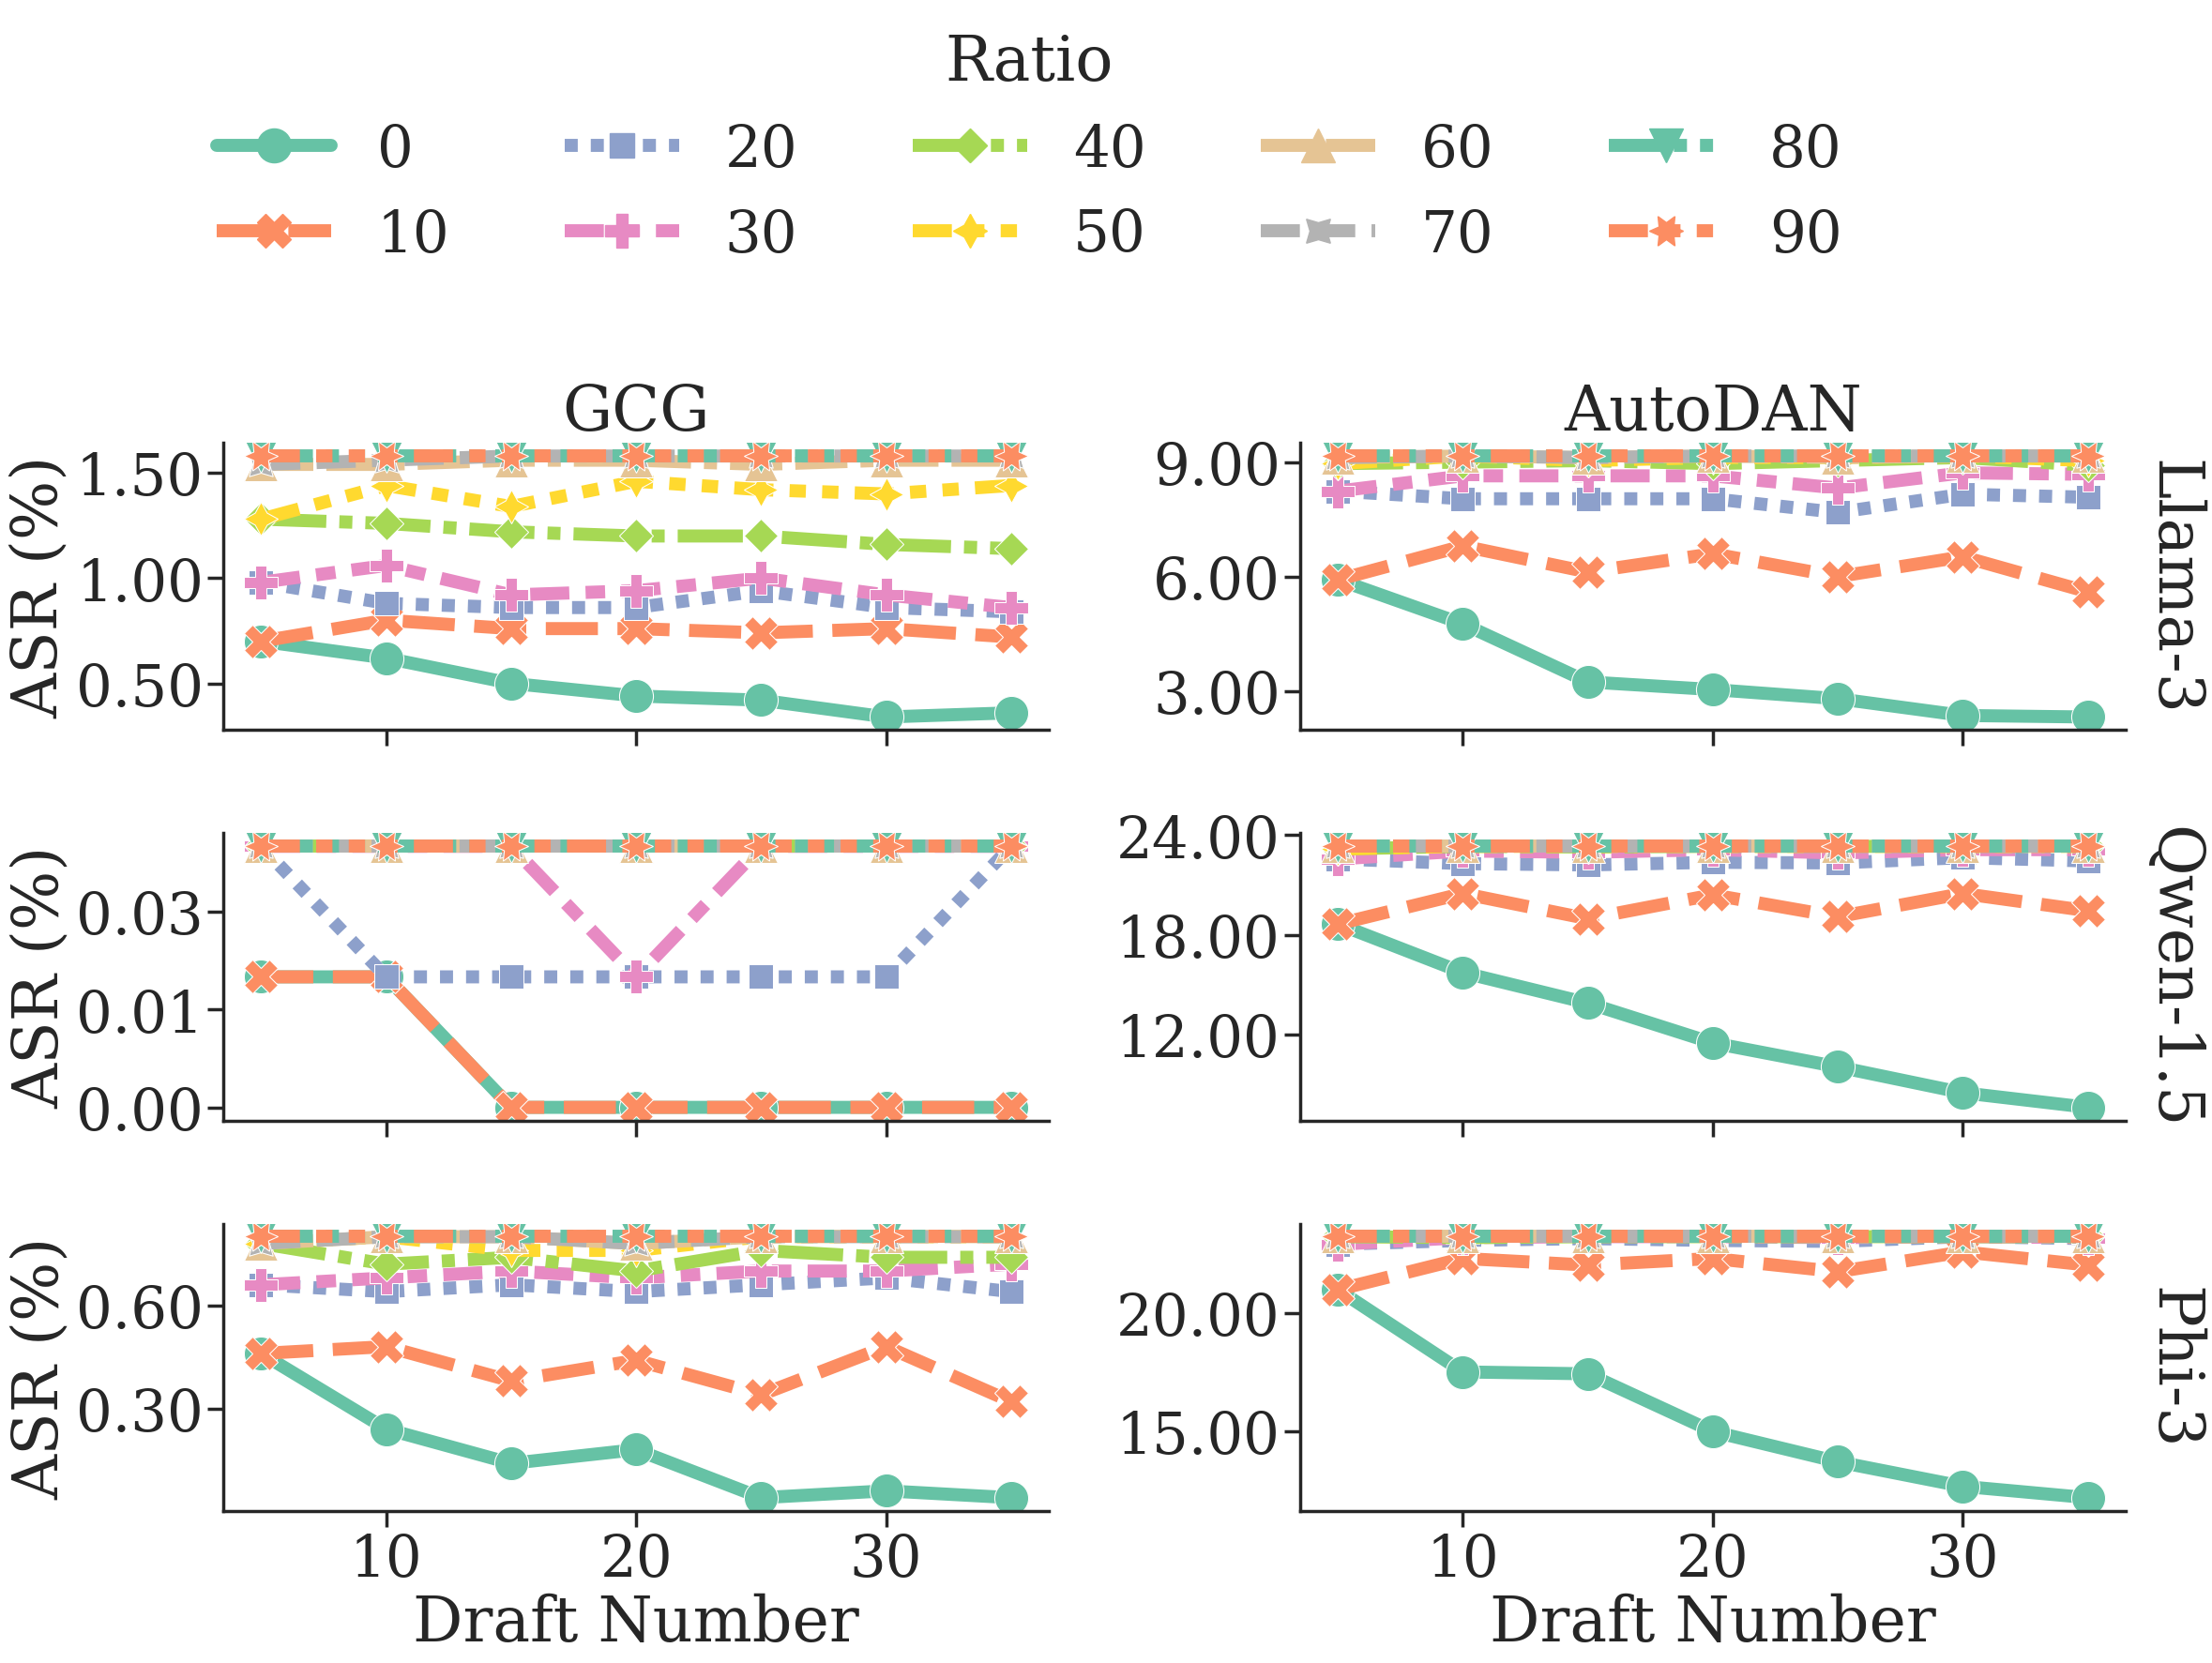

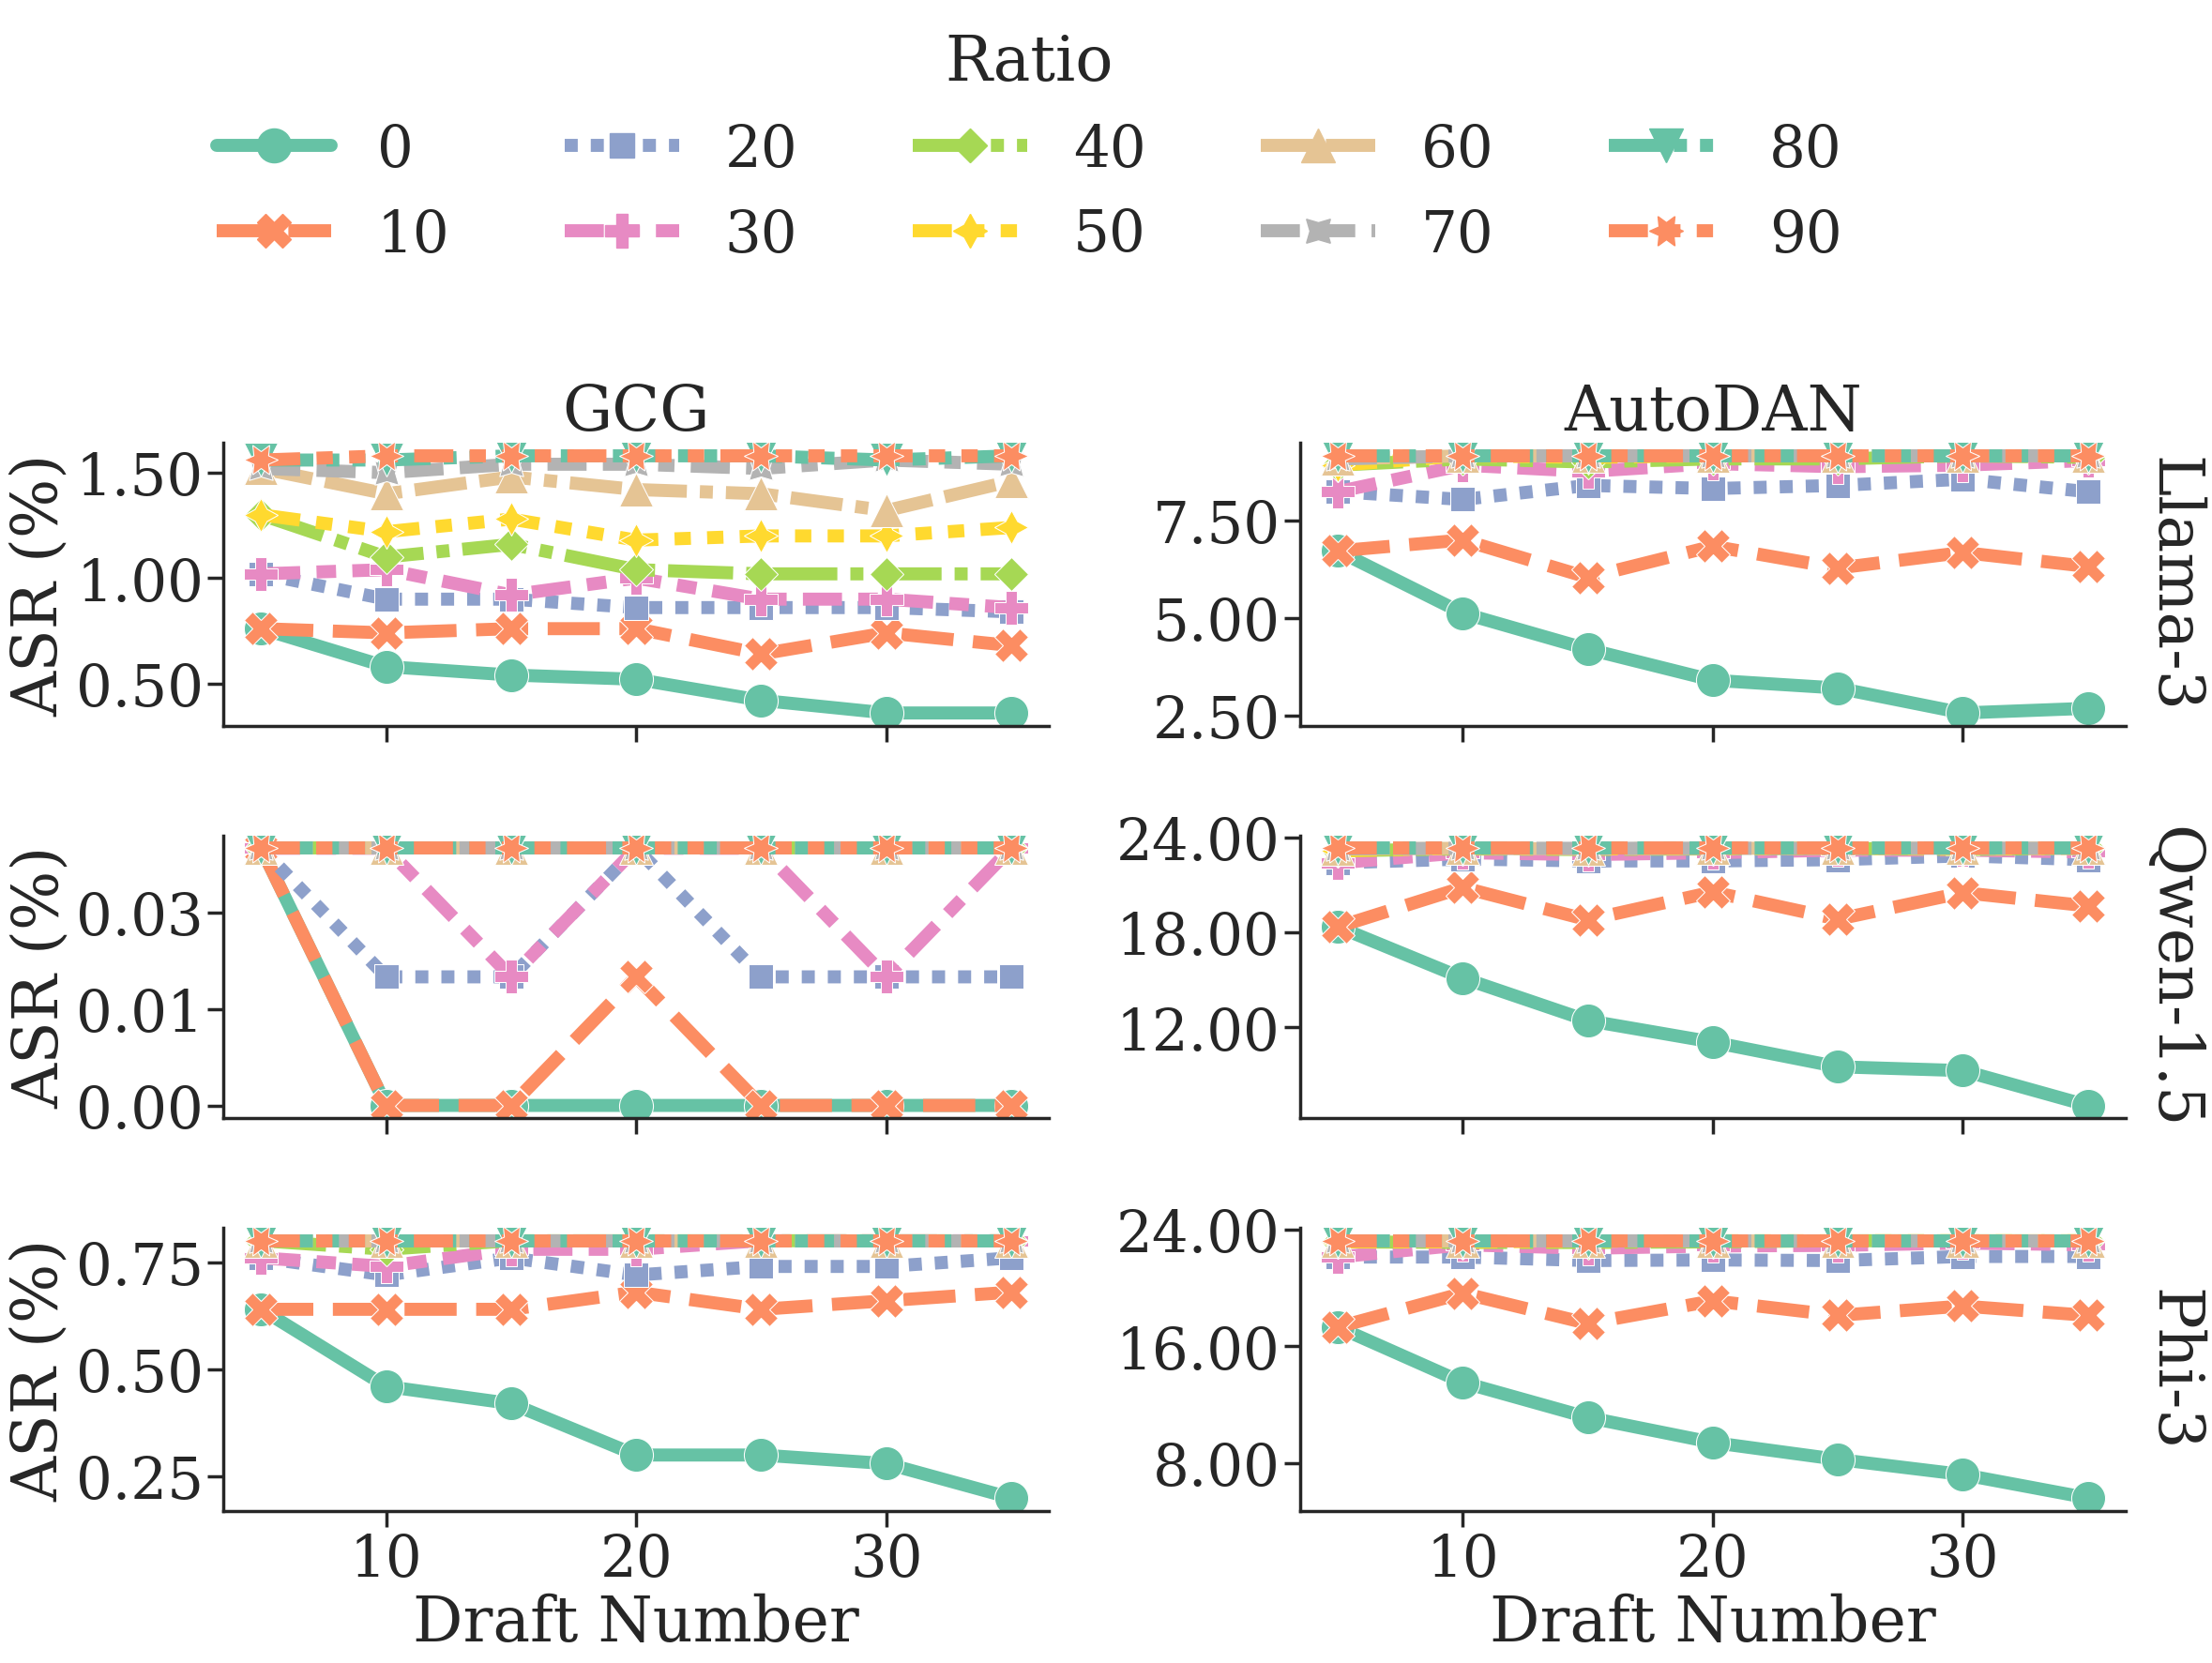

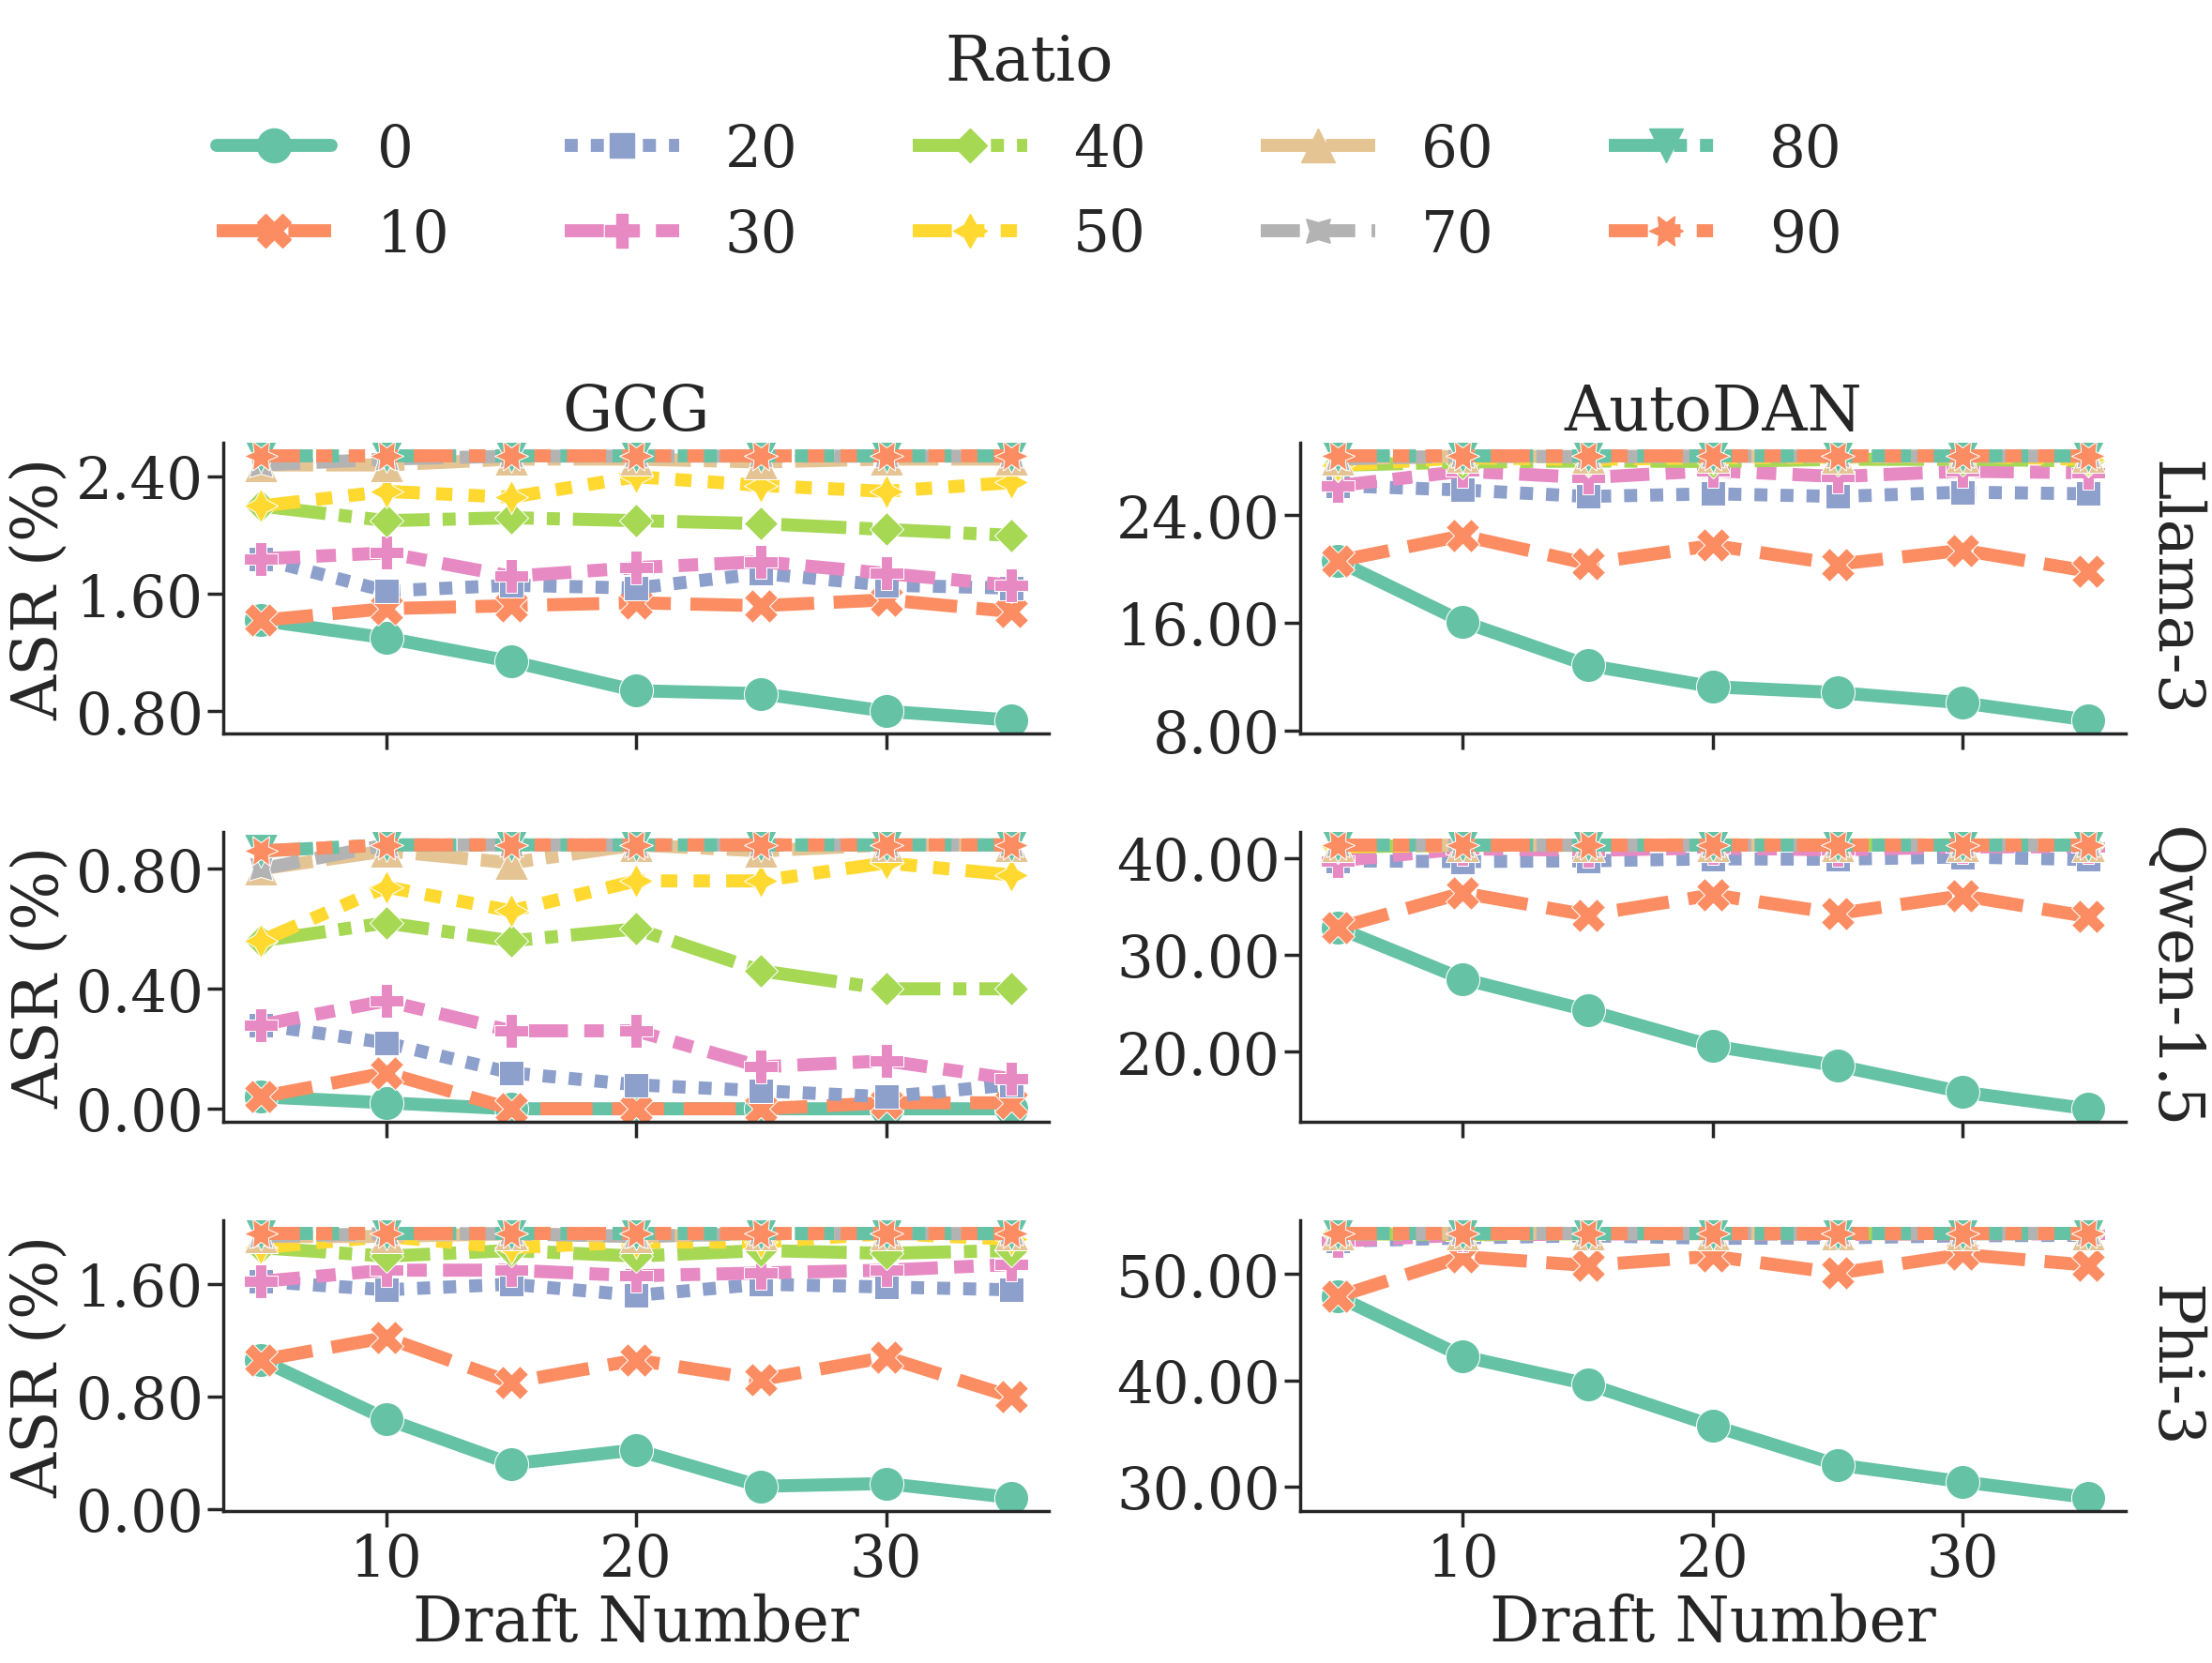

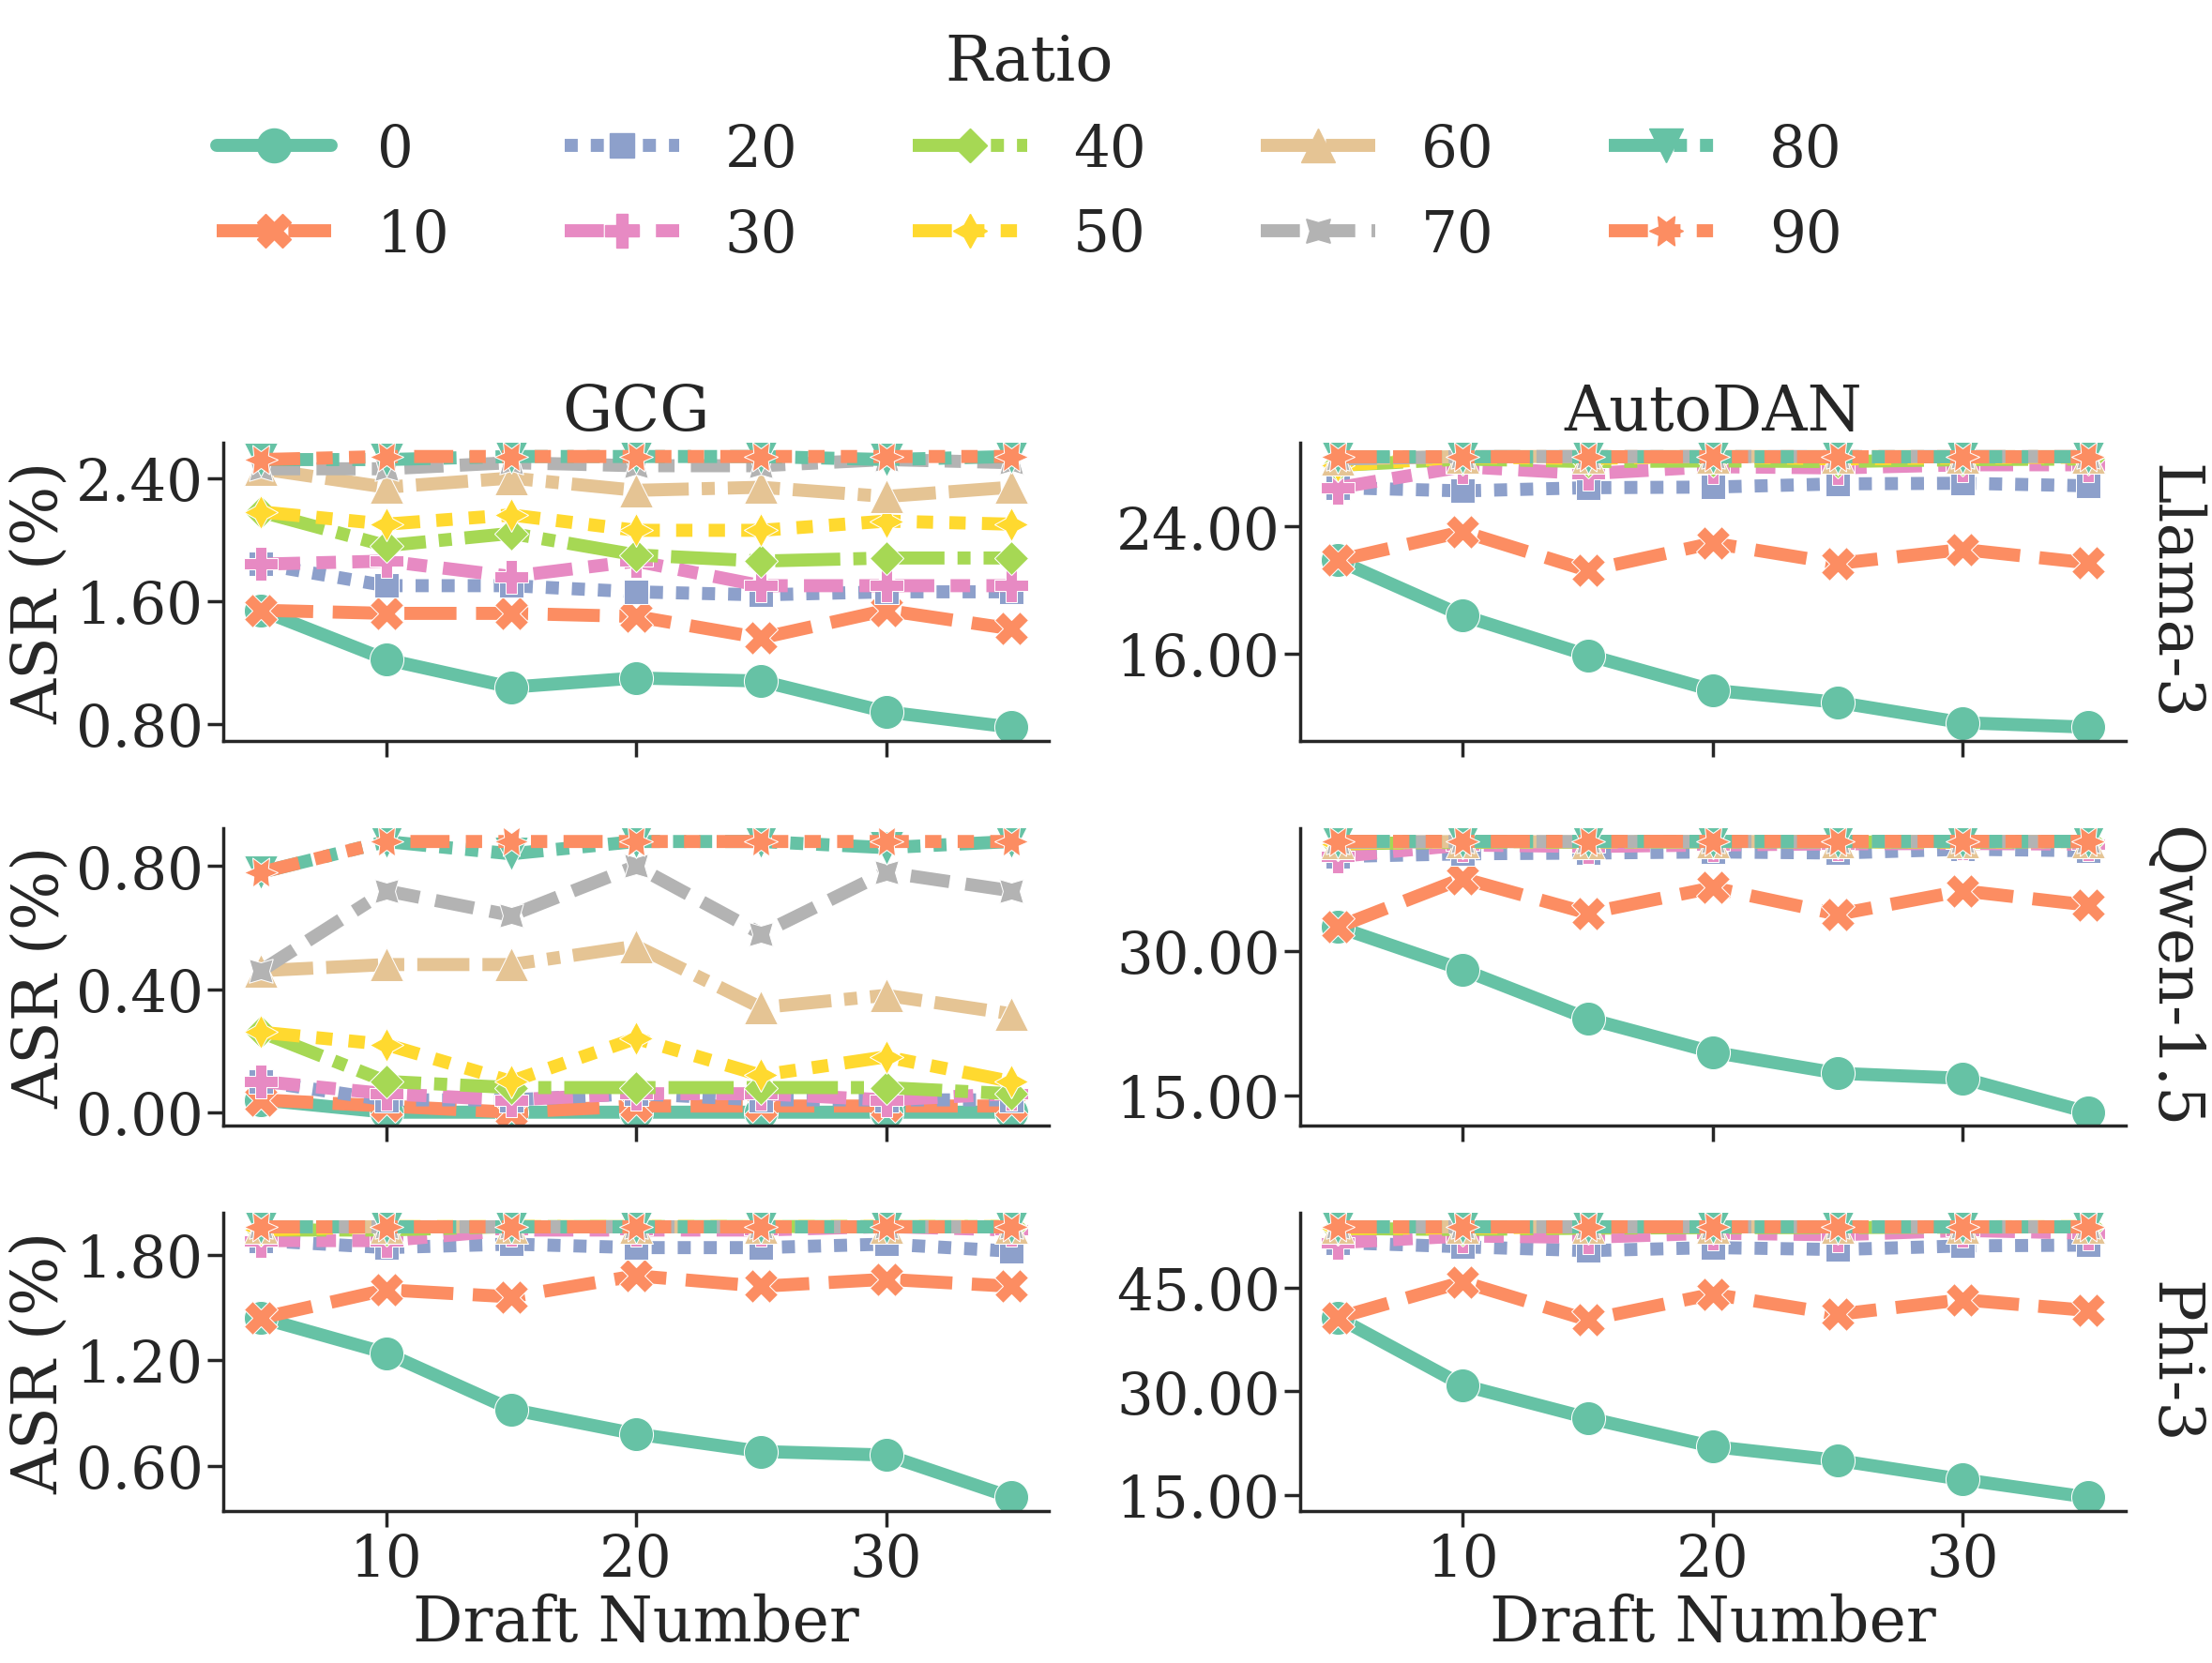

In [15]:
def plot_ASR(dataframe, x, hue, palette):
    figure = sns.relplot(
        data=dataframe,
        kind="line",
        x=x,
        y="ASR (%)",
        row="Target Model",
        col="Generation",
        hue=hue,
        style=hue,
        palette=palette,
        markers=True,
        markersize=26,
        linewidth=10,
        aspect=2.6,
        facet_kws={"margin_titles": True, "sharey": False},
    )
    # figure.set_titles("")
    figure.set_titles(row_template="{row_name}", col_template="{col_name}")

    for ax in figure.axes.flat:
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

    sns.move_legend(
        figure, "lower center",
        bbox_to_anchor=(.4, 1), ncol=5
    )

    figure.tight_layout()

    # plt.xlabel(x)
    # plt.ylabel("ASR")


for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
    df_1 = construct_dataframe(dataset_name, "opt-125m-AWQ", ground_truth_guard_name)
    df_2 = construct_dataframe(dataset_name, "SmolLM-135M", ground_truth_guard_name)
    df = pd.concat([df_1, df_2])
    df["ASR (%)"] = df["ASR"] * 100
    plot_ASR(
        df,
        "Ratio",
        "Draft Model",
        "Set1"
    )
    plt.savefig(
        figure_dir_path / f"ASR_ratio_{ground_truth_guard_name}.pdf",
        bbox_inches="tight",
        transparent="True",
        pad_inches=0,
    )

for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
    for draft_model_name in ["opt-125m-AWQ", "SmolLM-135M"]:
        df = construct_dataframe(
            dataset_name, draft_model_name, ground_truth_guard_name
        )
        df["ASR (%)"] = df["ASR"] * 100
        plot_ASR(
            df,
            "Draft Number",
            "Ratio",
            "Set2"
        )
        plt.savefig(
            figure_dir_path
            / f"ASR_draft_number_{ground_truth_guard_name}_{draft_model_name}.pdf",
            bbox_inches="tight",
            transparent="True",
            pad_inches=0,
        )

In [16]:
# def plot_by_draft_number(dataset_name, target_model_name, generation_name, draft_model_name):
#     for ratio in range(0, 100, 10):
#         draft_number_list = range(5, 35 + 1, 5)
#         y = []
#         for draft_number in draft_number_list:
#             ratio_percentage = ratio / 100
#             path = f"../../workdir/step_7_result/{dataset_name}/{target_model_name}/{generation_name}/{draft_model_name}/GPT_{ratio_percentage}.pkl"
#             df = pd.read_pickle(path)
#             ASR = df.loc[f"sandbox_{draft_number}"]["ASR"]
#             y.append(ASR)
#         y = np.array(y) * 100
#         plt.plot(draft_number_list, y, label=f"draft {draft_number}")


# plot_by_draft_number("RPAB", "Meta-Llama-3-70B-Instruct-AWQ", "GCG", "opt-125m-AWQ")

In [17]:
# # print current working directory
# import os
# print(os.getcwd())

# def draw(df, ax):
#     sns.barplot(df["ASR"]*100, fill=False, palette="Set1", ax=ax)
#     for container in ax.containers:
#         ax.bar_label(container, fmt='%.1f', label_type='edge')

#     # ax2 = plt.twinx()
#     # sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")

#     # ax.set_xticklabels(ax.get_xticklabels()) # rotation=45,ha="right",rotation_mode='anchor'
#     ax.set_ylim(top=ax.get_ylim()[1] * 1.2)

#     hatches = ['\\', '+', '//', '.', '|']
#     for bars, hatch in zip(ax.containers, hatches):
#         for bar in bars:
#             bar.set_hatch(hatch)

# fig, axes = plt.subplots(1, 2, figsize=(12, 2.2))

# for i, generation_name in enumerate(['GCG', 'AutoDAN']):
#     path = f"../../workdir/step_7_result/RPAB/Meta-Llama-3-70B-Instruct-AWQ/{generation_name}/opt-125m-AWQ/GPT_0.1.pkl"
#     ax = axes[i]

#     df = pd.read_pickle(path)

#     df = df.loc[['NA', 'PromptGuard', 'LlamaGuardPrompt', 'LlamaGuardPromptResponse', 'LlamaGuardPrompt_and_LlamaGuardPromptResponse', 'sandbox_5']]
#     df.index = ['N/A', 'PG(P)', 'LG(P)', 'LG(PR)', 'LG(P+PR)', 'Sandbox']

#     draw(df, ax)

#     if i == 0:
#         ax.set(ylabel="ASR (%)")
#     else:
#         # hide y label
#         ax.set(ylabel=None)

# plt.tight_layout()

# plt.savefig(r"C:\Users\htsai\src\2024-Defend-Transferable-Jailbreak-with-Speculative-Inference\figures\ASR_llama_bar.eps", bbox_inches='tight', transparent="True", pad_inches=0)

# plt.show()

# plt.clf()
# # sns.lineplot(df["average_time_for_successful_defense"])

In [18]:
# ax = sns.barplot(df["average_time_for_successful_defense"])
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.3f', label_type='edge')

# # ax2 = plt.twinx()
# # sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")

# ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode='anchor')